$$Resume Screening System$$


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Resume.csv")


In [3]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [4]:
df.info()
df['Category'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
ENGINEERING               118
ACCOUNTANT                118
FINANCE                   118
FITNESS                   117
AVIATION                  117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

In [5]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [6]:
df.shape

(2484, 4)

In [7]:
no_of_classes = df['Category'].value_counts().count()
no_of_classes

np.int64(24)

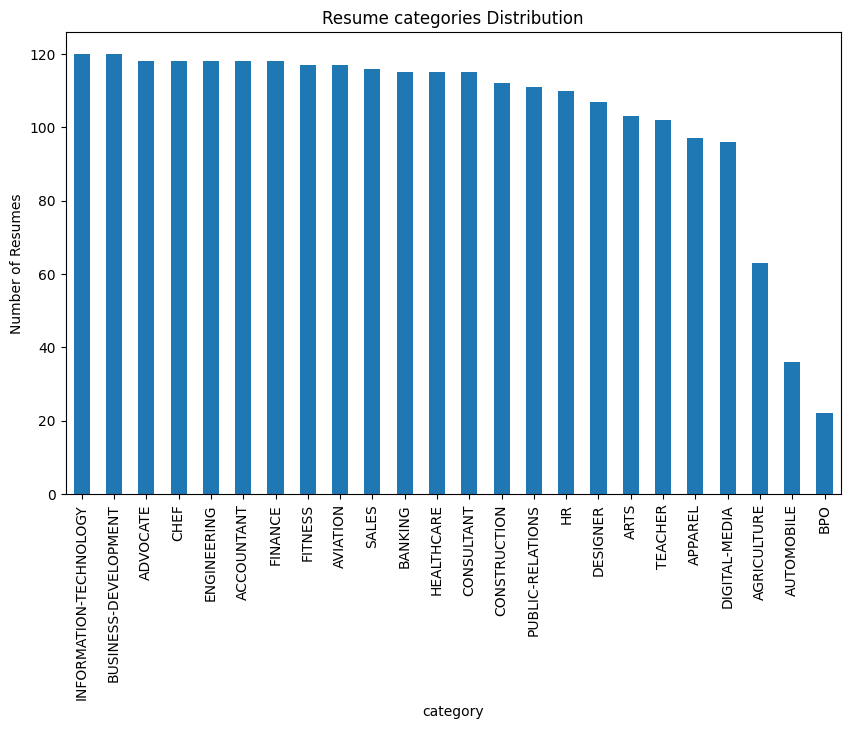

In [8]:
df['Category'].value_counts().plot(kind = 'bar',figsize=(10,6))
plt.xlabel('category')
plt.ylabel('Number of Resumes')
plt.title('Resume categories Distribution')
plt.show()

<Axes: xlabel='count', ylabel='Category'>

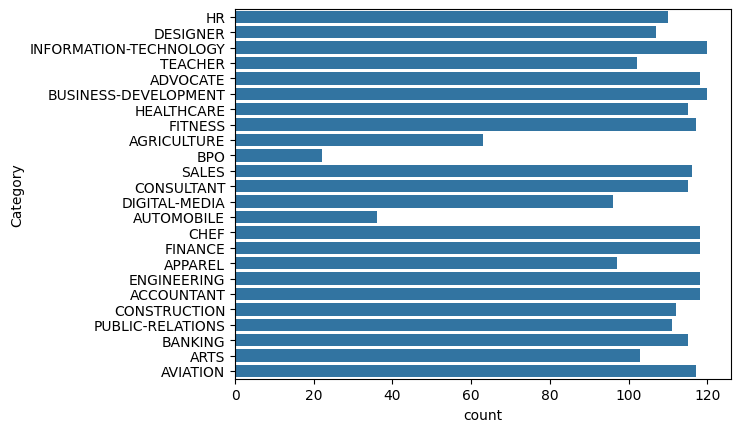

In [9]:
sns.countplot(y=df['Category'])


In [10]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [11]:
df['Resume_str'].iloc[0][:1000]

'         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss pr

In [12]:
X = df['Resume_str']
y = df['Category']

In [13]:
df['Category'].unique()

array(['HR', 'DESIGNER', 'INFORMATION-TECHNOLOGY', 'TEACHER', 'ADVOCATE',
       'BUSINESS-DEVELOPMENT', 'HEALTHCARE', 'FITNESS', 'AGRICULTURE',
       'BPO', 'SALES', 'CONSULTANT', 'DIGITAL-MEDIA', 'AUTOMOBILE',
       'CHEF', 'FINANCE', 'APPAREL', 'ENGINEERING', 'ACCOUNTANT',
       'CONSTRUCTION', 'PUBLIC-RELATIONS', 'BANKING', 'ARTS', 'AVIATION'],
      dtype=object)

In [14]:
df['Resume_str'].iloc[0]

"         HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      Missouri DOT Supervisor Training Certification  Certified by IHG in Customer Loyalty and Marketing by Segment   Hilton Worldwide General Manager Training Certification  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , Fidelio    OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss pr

$$NLP$$ $$IMPORTANT$$ $$LIBRARIES$$

In [15]:

import re
import nltk
import string


In [16]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+',' ',text)
    text = re.sub(r'\S+@+\S+',' ',text)
    text = re.sub(r'\d+',' ',text)
    text = text.translate(str.maketrans('','',string.punctuation))
    text = re.sub(r'\s+',' ',text)

    return text

In [17]:
clean_text(df['Resume_str'].iloc[0])

' hr administratormarketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customerfocused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multitasker client relations specialist accomplishments missouri dot supervisor training certification certified by ihg in customer loyalty and marketing by segment hilton worldwide general manager training certification accomplished trainer for cross server hospitality systems such as hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment experience hr administratormarketing asso

In [18]:
def convert(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+','',text)
    text = re.sub(r'\S+@+\S+','',text)
    text = re.sub(r'\d+','',text)
    text = text.translate(str.maketrans('','',string.punctuation))
    text = re.sub(r'\s+',' ',text)
    return text
     

In [19]:
convert(df['Resume_str'].iloc[0])

' hr administratormarketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customerfocused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multitasker client relations specialist accomplishments missouri dot supervisor training certification certified by ihg in customer loyalty and marketing by segment hilton worldwide general manager training certification accomplished trainer for cross server hospitality systems such as hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment experience hr administratormarketing asso

In [20]:
df['Cleaned_resume'] = df['Resume_str'].apply(convert)

In [21]:
df["Cleaned_resume"].iloc[0]

' hr administratormarketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customerfocused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multitasker client relations specialist accomplishments missouri dot supervisor training certification certified by ihg in customer loyalty and marketing by segment hilton worldwide general manager training certification accomplished trainer for cross server hospitality systems such as hilton onq micros opera pms fidelio opera reservation system ors holidex completed courses and seminars in customer service sales strategies inventory control loss prevention safety time management leadership and performance assessment experience hr administratormarketing asso

In [22]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\murli
[nltk_data]     mishra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
# nltk natural language toolkit for removing stopwords for unnecessary words like  'i','am' etc
from nltk.corpus import stopwords
words = df['Cleaned_resume'].iloc[0].split()
filtered = list(set([word for word in words if word not in stopwords.words('english')]))
stop_words = set(stopwords.words('english'))
stop_words.discard('not')
stop_words.discard('no')
stop_words.discard('without')

In [24]:
df["Cleaned_resume"] = df["Cleaned_resume"].apply(
    lambda x:" ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

In [25]:
df.head(5
        )

,ID,Resume_str,Resume_html,Category,Cleaned_resume
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administratormarketing associate hr adminis...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary years experience recruitin...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...


$$ MACHINE LEARNING $$ $$PART$$

In [26]:
from sklearn.preprocessing import LabelEncoder
categories = list(set([f for f in df['Category']]))
categories

['AVIATION',
 'ACCOUNTANT',
 'PUBLIC-RELATIONS',
 'FINANCE',
 'ENGINEERING',
 'BANKING',
 'BUSINESS-DEVELOPMENT',
 'DIGITAL-MEDIA',
 'AGRICULTURE',
 'CONSTRUCTION',
 'ARTS',
 'APPAREL',
 'ADVOCATE',
 'DESIGNER',
 'CONSULTANT',
 'SALES',
 'TEACHER',
 'FITNESS',
 'CHEF',
 'HR',
 'INFORMATION-TECHNOLOGY',
 'AUTOMOBILE',
 'BPO',
 'HEALTHCARE']

In [27]:
le = LabelEncoder()
encoded = le.fit_transform(categories)
encoded

array([ 6,  0, 21, 16, 15,  7,  9, 14,  2, 11,  4,  3,  1, 13, 12, 22, 23,
       17, 10, 19, 20,  5,  8, 18])

In [28]:
le.inverse_transform([10])

array(['CHEF'], dtype='<U22')

In [29]:
df['Category_encoded'] = le.fit_transform(df['Category'])

In [30]:
df.head()

,ID,Resume_str,Resume_html,Category,Cleaned_resume,Category_encoded
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administratormarketing associate hr adminis...,19
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...,19
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary years experience recruitin...,19
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven dynamic...,19
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...,19


In [31]:
df[['Category' , 'Category_encoded']].head()

,Category,Category_encoded
0,HR,19
1,HR,19
2,HR,19
3,HR,19
4,HR,19


In [32]:
X = df['Cleaned_resume']
y = df['Category']

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=10000,ngram_range=(1,2),min_df=2)
X = tfidf.fit_transform(df['Cleaned_resume'])

In [34]:
X.shape

(2484, 5000)

In [35]:
len(tfidf.vocabulary_)

5000

In [55]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# stratify = y This keeps the class distribution similar in train and test sets.

In [56]:
X_train.shape

(1987, 10000)

In [57]:
X_test.shape

(497, 10000)

In [58]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [59]:
y_pred = nb.predict(X_test)

In [60]:
text = ["computer technology"]
ok = tfidf.transform(text)
pred = nb.predict(ok)
print(pred)




['INFORMATION-TECHNOLOGY']


In [61]:
le.classes_

array(['ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS',
       'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT',
       'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA',
       'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR',
       'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER'],
      dtype=object)

In [62]:
print(type(X_train))
print(X_train.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(1987, 10000)


In [63]:
mapping = (
    df[['Category','Category_encoded']]
    .drop_duplicates()
    .set_index('Category_encoded')['Category'].to_dict()
)

In [64]:
mapping

{19: 'HR',
 13: 'DESIGNER',
 20: 'INFORMATION-TECHNOLOGY',
 23: 'TEACHER',
 1: 'ADVOCATE',
 9: 'BUSINESS-DEVELOPMENT',
 18: 'HEALTHCARE',
 17: 'FITNESS',
 2: 'AGRICULTURE',
 8: 'BPO',
 22: 'SALES',
 12: 'CONSULTANT',
 14: 'DIGITAL-MEDIA',
 5: 'AUTOMOBILE',
 10: 'CHEF',
 16: 'FINANCE',
 3: 'APPAREL',
 15: 'ENGINEERING',
 0: 'ACCOUNTANT',
 11: 'CONSTRUCTION',
 21: 'PUBLIC-RELATIONS',
 7: 'BANKING',
 4: 'ARTS',
 6: 'AVIATION'}

In [67]:
#Accuracy 
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)


0.5613682092555332

In [66]:
#classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.51      0.88      0.65        24
              ADVOCATE       0.32      0.42      0.36        24
           AGRICULTURE       1.00      0.08      0.14        13
               APPAREL       0.50      0.05      0.10        19
                  ARTS       1.00      0.14      0.25        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.82      0.58      0.68        24
               BANKING       0.88      0.61      0.72        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.39      0.92      0.54        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.67      0.73      0.70        22
            CONSULTANT       1.00      0.04      0.08        23
              DESIGNER       0.75      0.57      0.65        21
         DIGITAL-MEDIA       0.75      

c:\Users\murli mishra\OneDrive\Desktop\PYTHON\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\murli mishra\OneDrive\Desktop\PYTHON\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\murli mishra\OneDrive\Desktop\PYTHON\tf_env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

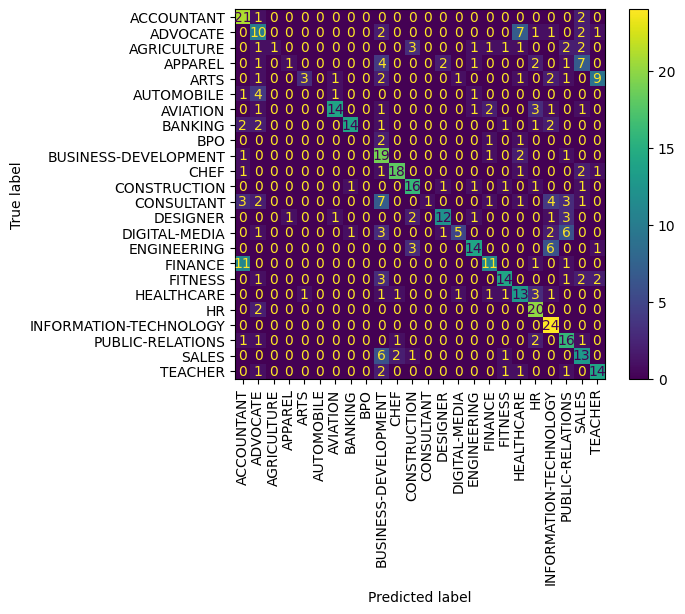

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation='vertical'
)

In [70]:
# TRYING LOGISTIC REGRESSION 
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_pred_lr = lr.predict(X_test)
print(accuracy_score(y_test,y_pred_lr))
# ACCURACY IS 0.65 better than Naive-Bayes


0.6639839034205232


In [69]:
# Linear SVM
from sklearn.svm import LinearSVC
svm = LinearSVC()
svm.fit(X_train,y_train)

y_pred_svm = svm.predict(X_test)
print(accuracy_score(y_pred_svm,y_test))
# it is better than Logistic Regression

0.7323943661971831


In [68]:
print(classification_report(y_test, y_pred_svm))

                        precision    recall  f1-score   support

            ACCOUNTANT       0.72      0.88      0.79        24
              ADVOCATE       0.61      0.79      0.69        24
           AGRICULTURE       0.88      0.54      0.67        13
               APPAREL       0.60      0.32      0.41        19
                  ARTS       0.60      0.43      0.50        21
            AUTOMOBILE       1.00      0.43      0.60         7
              AVIATION       0.82      0.75      0.78        24
               BANKING       0.77      0.74      0.76        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.55      0.75      0.63        24
                  CHEF       0.82      0.75      0.78        24
          CONSTRUCTION       0.79      0.86      0.83        22
            CONSULTANT       0.73      0.35      0.47        23
              DESIGNER       0.91      0.95      0.93        21
         DIGITAL-MEDIA       0.69      

In [71]:
# saving the data into pickle file
import pickle
pickle.dump(svm,
            open('svm.pkl','wb'))
pickle.dump(tfidf,
            open('tfidf.pkl','wb'))
pickle.dump(le,
            open('label_encoder.pkl','wb'))